# Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import h5py

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

In [2]:
# use latex
plt.rc('text', usetex=True)
# set font size
plt.rc('font', size=14)

## Analysis on Response Regulators

In [3]:
methods = ["onehot", "rbm", "foundation", "msa_pairformer", "msa_transformer", "esm", "rbm_drelu"]
path_db = "../experiments/datasets/RR/t10.4_t2.07_pipe/"

In [4]:
from sklearn.preprocessing import label_binarize

def compute_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)
    return fpr, tpr, roc_auc

def multiclass_average_roc(y_true, y_probs, classes=None, num_interp_points=100):
    """
    Computes the average ROC curve and AUC score for multiclass classification.
    
    Parameters:
        y_true (array-like): True labels (shape: [n_samples])
        y_probs (array-like): Predicted probabilities (shape: [n_samples, n_classes])
        classes (array-like, optional): List of all class labels. If None, inferred from y_true.
        num_interp_points (int): number of intepolants.
        
    Returns:
        fpr (np.ndarray): np.linspace(0, 1, num_interp_points)
        tpr (np.ndarray): Mean true positive rates (averaged across classes).
        auc (float): Mean AUC score across classes.
    """
    if classes is None:
        classes = np.unique(y_true)
    y_true_bin = label_binarize(y_true, classes=classes)
    
    fpr = np.linspace(0, 1, num_interp_points)
    tpr = dict()
    roc_auc = dict()
    for i, c in enumerate(classes):
        fpr_class, tpr_class, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[c] = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
        tpr[c] = np.interp(fpr, fpr_class, tpr_class)
    
    mean_tpr = np.vstack([tpr[c] for c in classes]).mean(0)
    mean_auc = np.array([roc_auc[c] for c in classes]).mean()
    
    return fpr, mean_tpr, mean_auc

Processing file: seed_1.test.onehot.predictions.h5
Processing file: seed_1.test.rbm.predictions.h5
Processing file: seed_1.test.foundation.predictions.h5
Processing file: seed_1.test.msa_pairformer.predictions.h5
Processing file: seed_1.test.esm.predictions.h5
Processing file: seed_1.test.msa_transformer.predictions.h5
Processing file: seed_1.test.rbm_drelu.predictions.h5


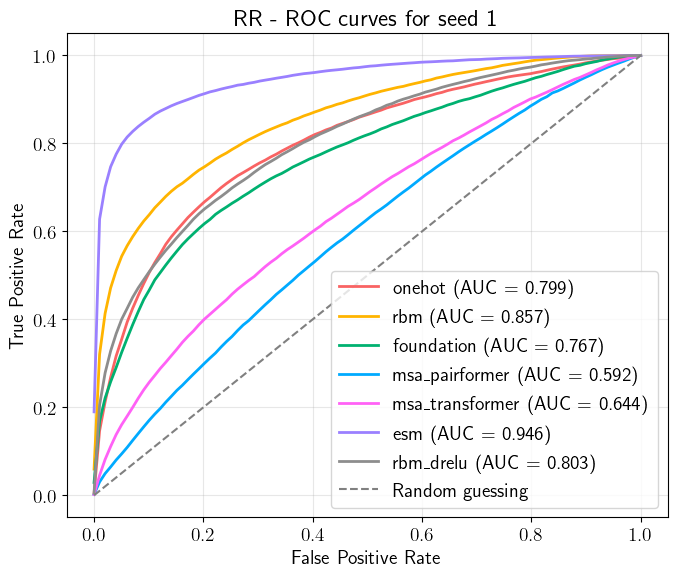

In [10]:
# Plot average ROC curves for one seed only
seed = 1
tpr_methods_seed1 = {method: [] for method in methods}
roc_auc_methods_seed1 = {method: [] for method in methods}

for filename in os.listdir(path_db):
    if not "predictions.h5" in filename:
        continue
    if not f"seed_{seed}." in filename:
        continue
    if "sample" in filename:
        continue
    
    print(f"Processing file: {filename}")
    method = filename.split(".")[-3]
    
    with h5py.File(os.path.join(path_db, filename), "r") as data:
        # Convert bytes back to strings for labels
        y_true = data["labels_true"][()].astype(str)
        y_prob = data["predictions"]["logreg"]["labels_probs"][()]
        fpr_seed1, tpr_seed1, roc_auc_seed1 = multiclass_average_roc(y_true, y_prob)
        tpr_methods_seed1[method] = tpr_seed1
        roc_auc_methods_seed1[method] = roc_auc_seed1

# Plot ROC curves for seed_1
colors_method = {
    "onehot": "#f96363",
    "rbm": "#ffb400",
    "foundation": "#00b170",
    "msa_pairformer": "#00aaff",
    "msa_transformer": "#ff61f6",
    "esm": "#9a80ff",
    "rbm_drelu": "#8d8d8d",
}

fig, ax = plt.subplots(figsize=(7, 6), dpi=100)

for method in methods:
    if method in tpr_methods_seed1 and len(tpr_methods_seed1[method]) > 0:
        color = colors_method.get(method, f"C{methods.index(method)}")
        ax.plot(fpr_seed1, tpr_methods_seed1[method], color=color,
                label=fr"{method} (AUC = {roc_auc_methods_seed1[method]:.3f})",
                linewidth=2)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing', linewidth=1.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'RR - ROC curves for seed {seed}')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
tpr_methods = {method: [] for method in methods}
roc_auc_methods = {method: [] for method in methods}
fpr = np.linspace(0, 1, 100)

for filename in os.listdir(path_db):
    if not "predictions.h5" in filename:
        continue
    print(f"Processing file: {filename}")
    seed = int(filename.split("seed_")[1].split(".")[0])
    method = filename.split(".")[-3]
    
    with h5py.File(os.path.join(path_db, filename), "r") as data:
        # Convert bytes back to strings for labels
        y_true = data["labels_true"][()].astype(str)
        y_prob = data["predictions"]["logreg"]["labels_probs"][()]
        _, tpr, roc_auc = multiclass_average_roc(y_true, y_prob)
        tpr_methods[method].append(tpr)
        roc_auc_methods[method].append(roc_auc)

Processing file: seed_1.test.onehot.predictions.h5
Processing file: seed_1.test.rbm.predictions.h5
Processing file: seed_1.test.foundation.predictions.h5
Processing file: seed_1.test.foundation.predictions.h5
Processing file: seed_1.test.foundation.predictions.h5
Processing file: seed_1.test.msa_pairformer.predictions.h5
Processing file: seed_2.test.onehot.predictions.h5
Processing file: seed_1.test.msa_pairformer.predictions.h5
Processing file: seed_2.test.onehot.predictions.h5
Processing file: seed_1.test.msa_pairformer.predictions.h5
Processing file: seed_2.test.onehot.predictions.h5
Processing file: seed_2.test.rbm.predictions.h5
Processing file: seed_2.test.foundation.predictions.h5
Processing file: seed_2.test.rbm.predictions.h5
Processing file: seed_2.test.foundation.predictions.h5
Processing file: seed_2.test.rbm.predictions.h5
Processing file: seed_2.test.foundation.predictions.h5
Processing file: seed_2.test.msa_pairformer.predictions.h5
Processing file: seed_3.test.onehot.pr

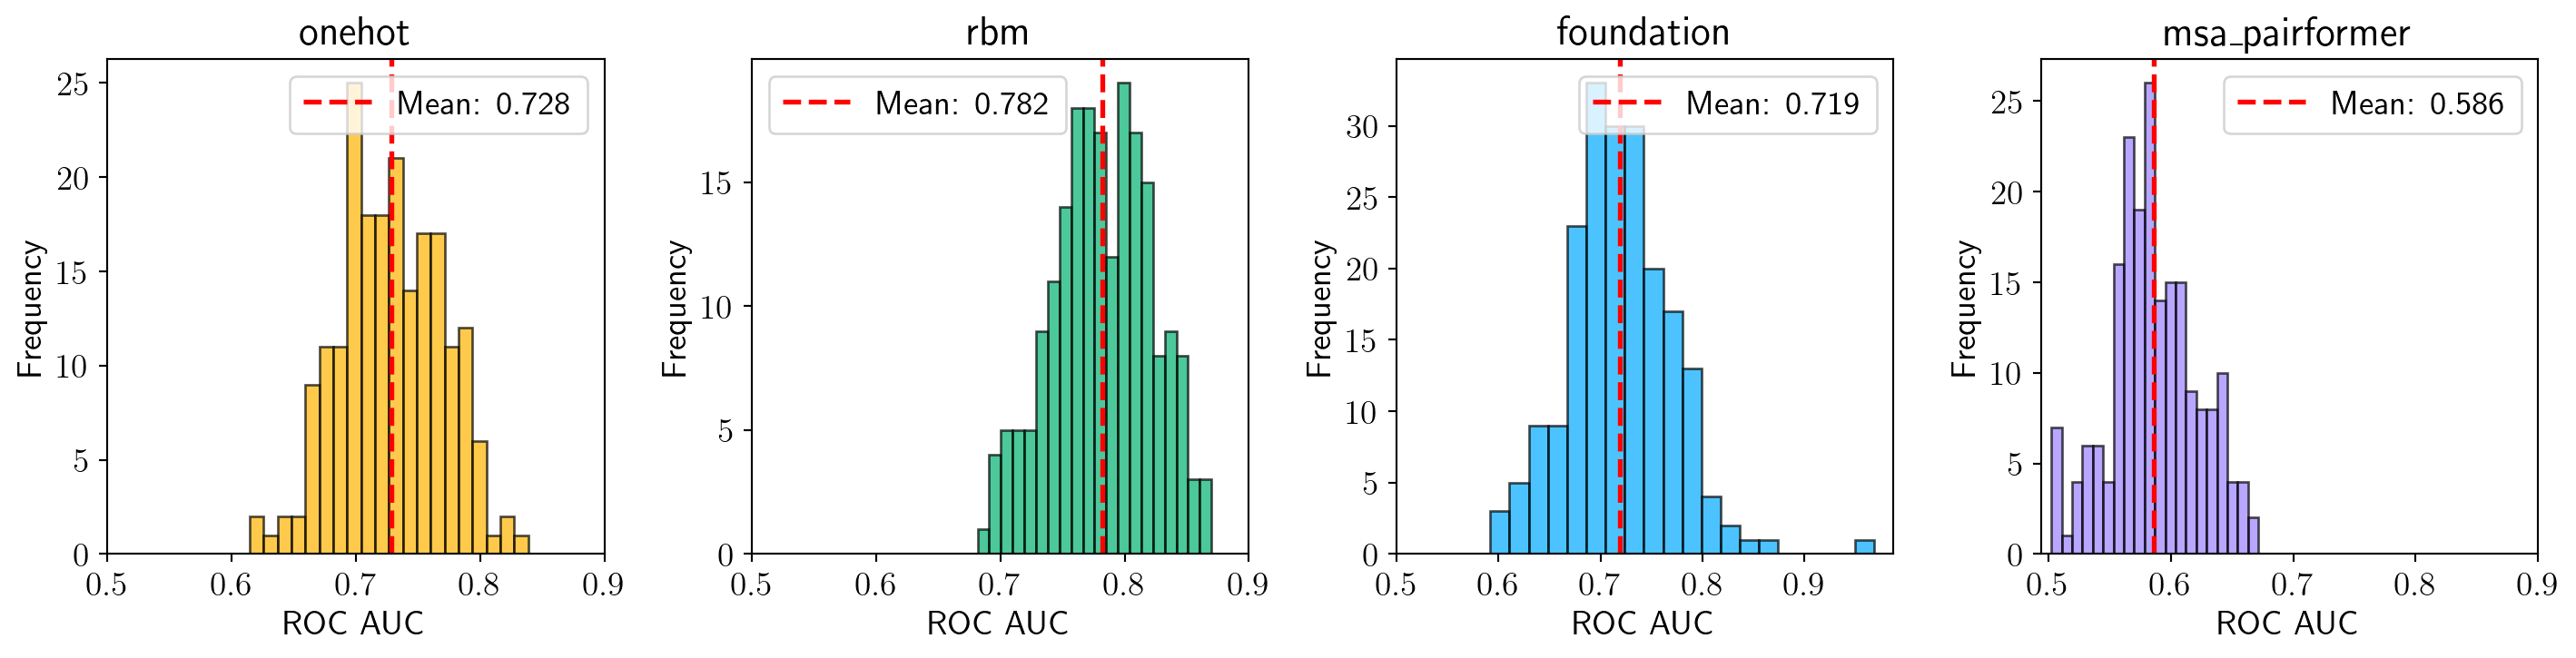

In [6]:
# Plot histograms of ROC AUC for each method
fig, axes = plt.subplots(1, len(methods), figsize=(15, 4), dpi=192)
colors_list = ["#ffb400", "#00b170", "#00aaff", "#9a80ff"]

for idx, method in enumerate(methods):
    ax = axes[idx]
    color = colors_list[idx] if idx < len(colors_list) else f"C{idx}"
    ax.hist(roc_auc_methods[method], bins=20, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('ROC AUC')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{method}')
    ax.axvline(np.mean(roc_auc_methods[method]), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(roc_auc_methods[method]):.3f}')
    ax.set_xticks(np.arange(0.5, 1., 0.1))
    ax.legend()

plt.tight_layout()
plt.show()

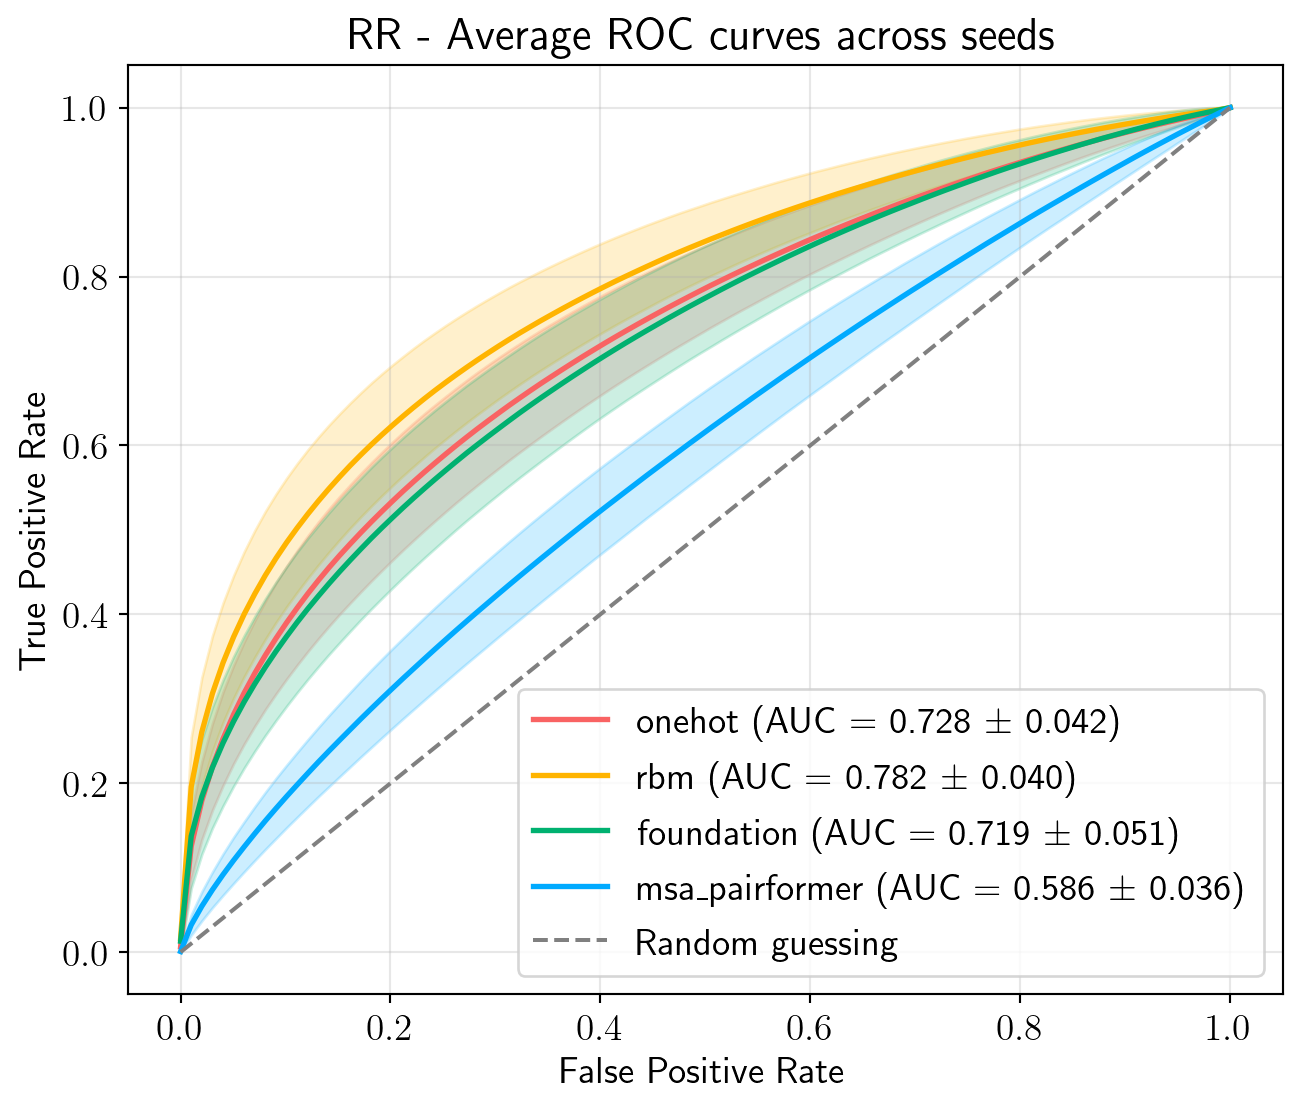

In [7]:
# Compute mean and std of TPR across seeds for each method
mean_tpr_methods = {}
std_tpr_methods = {}
mean_auc_methods = {}
std_auc_methods = {}

colors_method = {
    "onehot": "#f96363",
    "rbm": "#ffb400",
    "foundation": "#00b170",
    "msa_pairformer": "#00aaff"
}

for method in methods:
    mean_tpr_methods[method] = np.mean(tpr_methods[method], axis=0)
    std_tpr_methods[method] = np.std(tpr_methods[method], axis=0)
    mean_auc_methods[method] = np.mean(roc_auc_methods[method])
    std_auc_methods[method] = np.std(roc_auc_methods[method])

# Plot average ROC curves with shaded error regions
fig, ax = plt.subplots(figsize=(7, 6), dpi=192)

for method in methods:
    color = colors_method.get(method, f"C{methods.index(method)}")
    ax.plot(fpr, mean_tpr_methods[method], color=color,
            label=fr"{method} (AUC = {mean_auc_methods[method]:.3f} $\pm$ {std_auc_methods[method]:.3f})",
            linewidth=2)
    
    # Shaded error region
    tpr_upper = np.minimum(mean_tpr_methods[method] + std_tpr_methods[method], 1)
    tpr_lower = np.maximum(mean_tpr_methods[method] - std_tpr_methods[method], 0)
    ax.fill_between(fpr, tpr_lower, tpr_upper, color=color, alpha=0.2)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing', linewidth=1.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'RR - Average ROC curves across seeds')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Average across different seeds

In [8]:
# Compute F1 scores for each method and seed
df_f1_scores_all = pd.DataFrame()

for filename in os.listdir(path_db):
    if not "predictions.h5" in filename:
        continue
    
    seed = int(filename.split("seed_")[1].split(".")[0])
    method = filename.split(".")[-3]
    
    with h5py.File(os.path.join(path_db, filename), "r") as data:
        # Convert bytes back to strings for labels
        y_true = data["labels_true"][()].astype(str)
        
        # Get predictions for all classifiers
        for classifier in ["logreg", "SVM", "random_forest"]:
            y_pred = data[f"predictions/{classifier}/labels_pred"][()].astype(str)
            f1 = f1_score(y_true, y_pred, average='macro')
            
            df_f1_scores_all = pd.concat([df_f1_scores_all, pd.DataFrame([{
                "method": method,
                "classifier": classifier,
                "seed": seed,
                "f1_score": f1
            }])], ignore_index=True)

print(f"Collected F1 scores for {len(df_f1_scores_all)} combinations")

Collected F1 scores for 2412 combinations


## F1 Score Comparison with Sub-bars

In [9]:
# Select classifier for single-classifier plot
classifier_to_plot = "logreg"  # Options: "logreg", "SVM", "random_forest"

# Filter data for selected classifier
df_plot = df_f1_scores_all[df_f1_scores_all["classifier"] == classifier_to_plot].copy()

print(f"Plotting F1 scores for classifier: {classifier_to_plot}")
print(f"Number of data points: {len(df_plot)}")

Plotting F1 scores for classifier: logreg
Number of data points: 804


/tmp/ipykernel_2533529/661195354.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


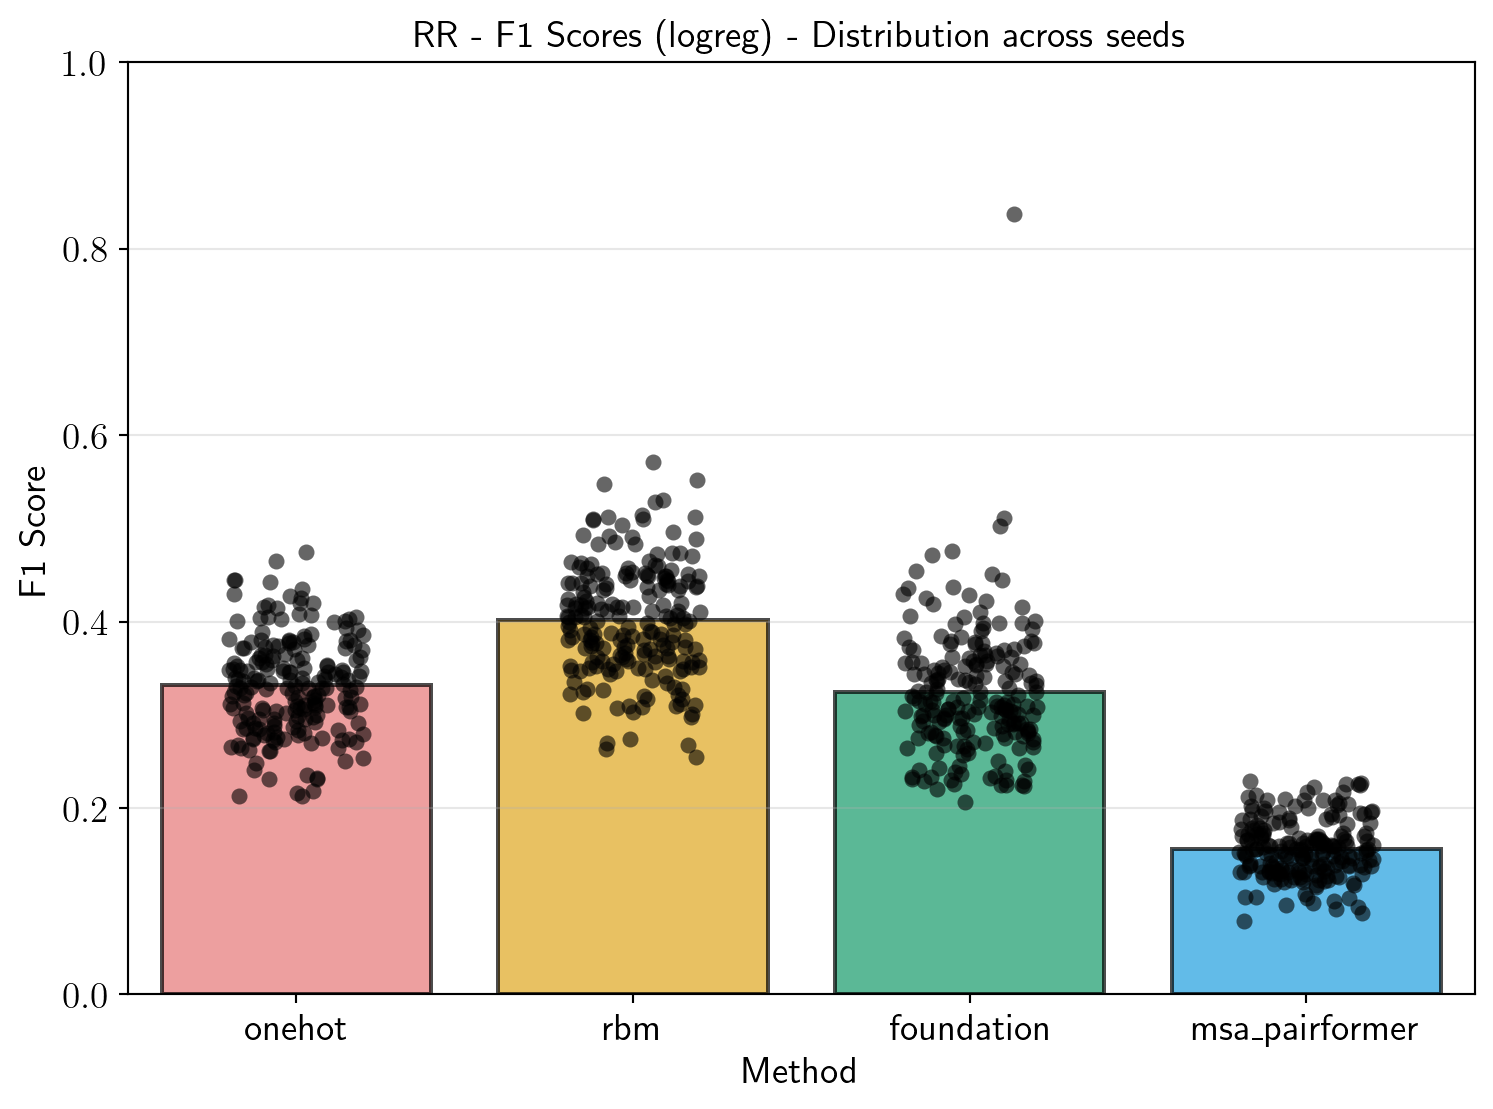

In [10]:
# Single classifier bar plot with distribution
fig, ax = plt.subplots(figsize=(8, 6), dpi=192)

# Create bar plot with mean values
sns.barplot(
    data=df_plot,
    x="method",
    y="f1_score",
    ax=ax,
    palette=colors_method,
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    errorbar=None
)

# Overlay individual data points (strip plot)
sns.stripplot(
    data=df_plot,
    x="method",
    y="f1_score",
    ax=ax,
    color="black",
    alpha=0.6,
    size=6,
    jitter=0.2
)

ax.set_ylabel(r"F1 Score", fontsize=14)
ax.set_xlabel("Method", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title(f"RR - F1 Scores ({classifier_to_plot}) - Distribution across seeds", fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

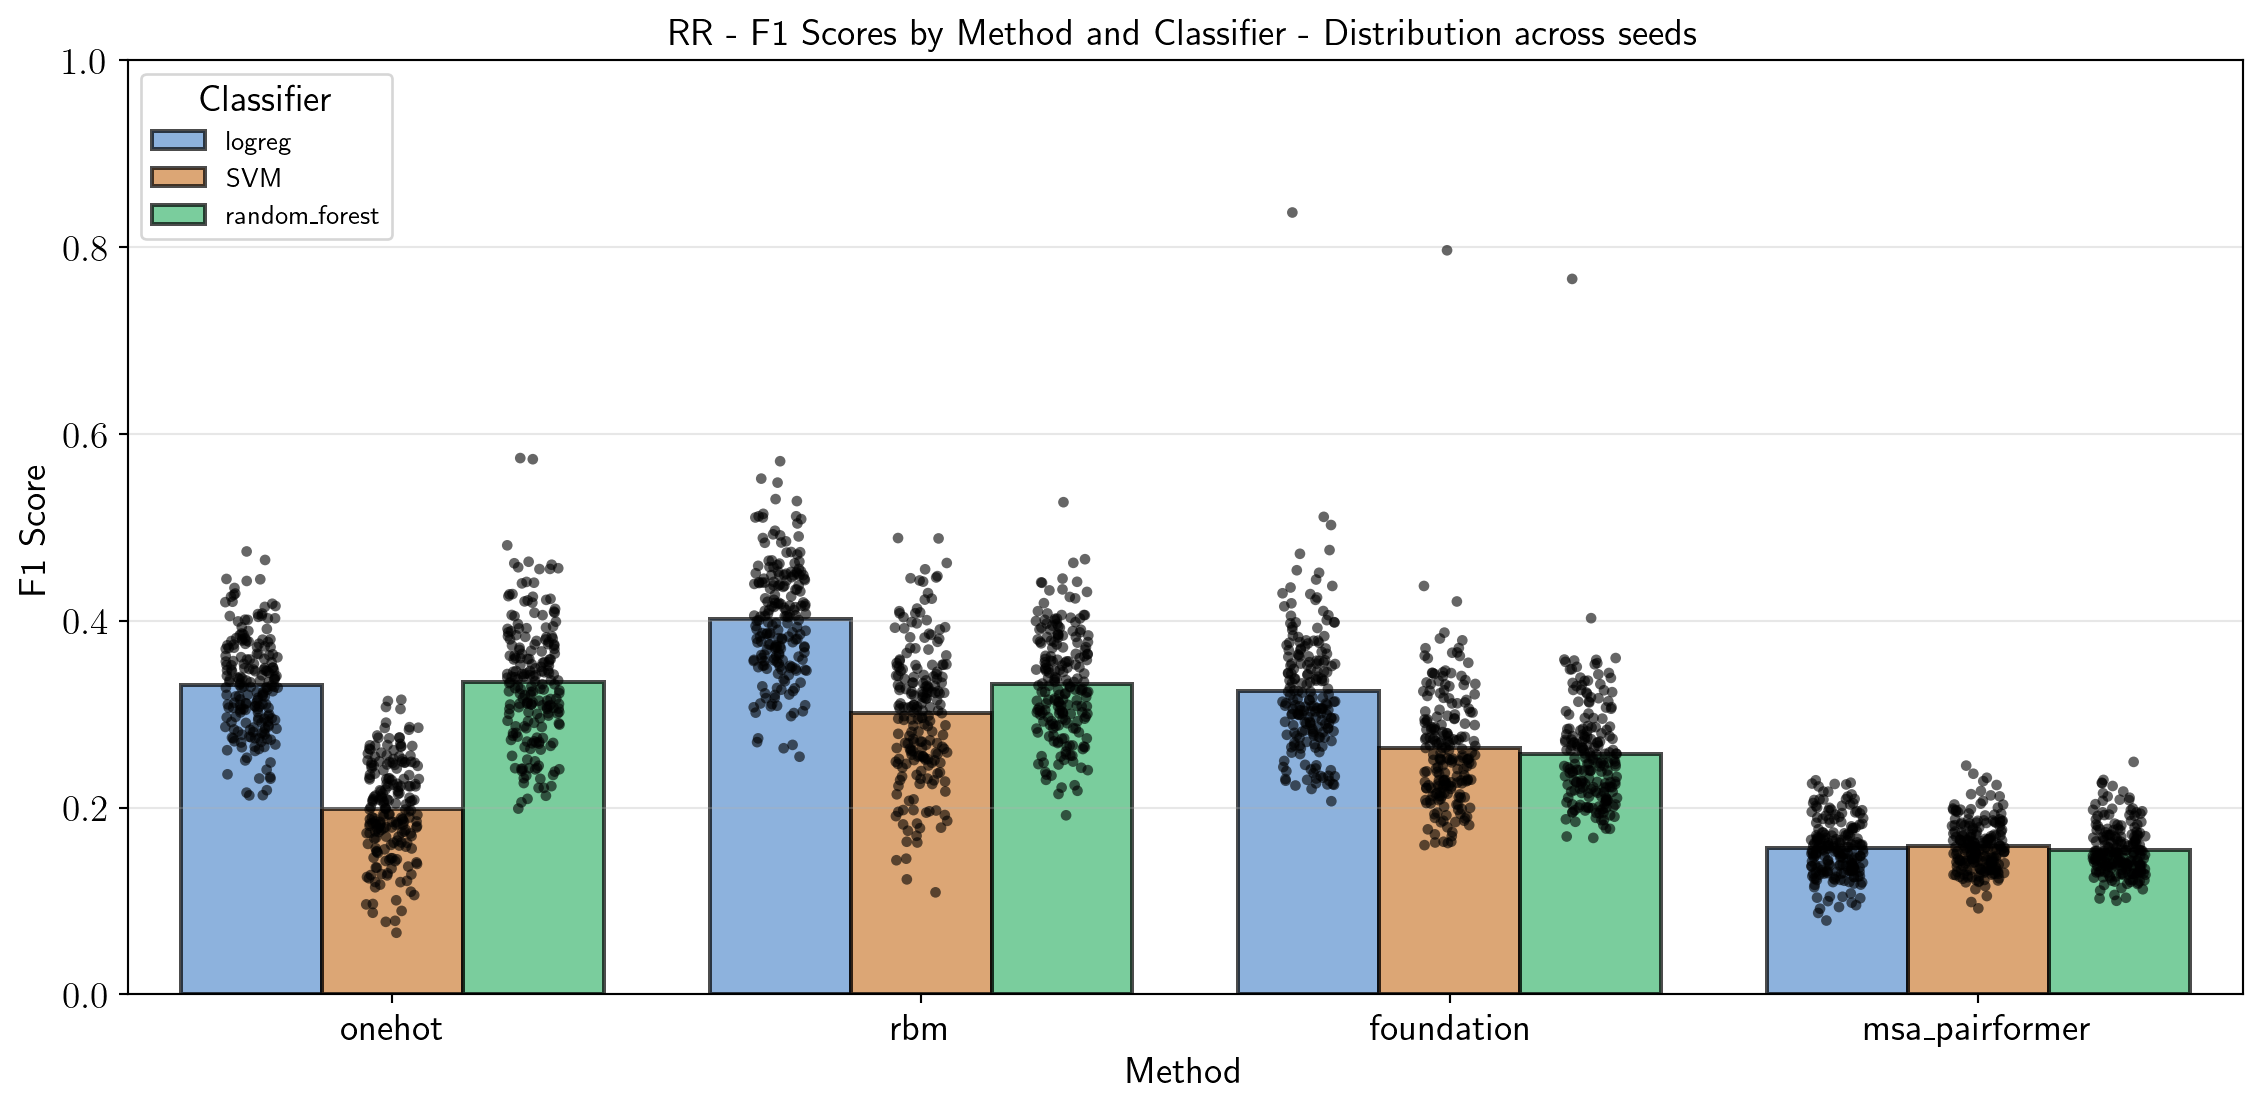

In [11]:
# Grouped bar plot with sub-bars for all classifiers
fig, ax = plt.subplots(figsize=(12, 6), dpi=192)

# Define color palette for classifiers
classifier_palette = {
    "logreg": "#4a90e2",
    "SVM": "#e67e22",
    "random_forest": "#2ecc71"
}

# Create grouped bar plot with mean values
bar_plot = sns.barplot(
    data=df_f1_scores_all,
    x="method",
    y="f1_score",
    hue="classifier",
    ax=ax,
    palette=classifier_palette,
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    errorbar=None
)

# Overlay individual data points (strip plot) with dodge for grouped bars
sns.stripplot(
    data=df_f1_scores_all,
    x="method",
    y="f1_score",
    hue="classifier",
    ax=ax,
    palette=["black"]*3,
    alpha=0.6,
    size=4,
    jitter=0.15,
    dodge=True,
    legend=False
)

ax.set_ylabel(r"F1 Score", fontsize=14)
ax.set_xlabel("Method", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title(f"RR - F1 Scores by Method and Classifier - Distribution across seeds", fontsize=14)
ax.legend(title="Classifier", loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Distribution Analysis - Foundation + LogReg

In [12]:
from scipy import stats

# Extract data for foundation model with logistic regression
foundation_roc_auc = np.array(roc_auc_methods["foundation"])
foundation_f1 = df_f1_scores_all[
    (df_f1_scores_all["method"] == "foundation") & 
    (df_f1_scores_all["classifier"] == "logreg")
]["f1_score"].values

# Fit Gaussian distributions
roc_auc_mean, roc_auc_std = foundation_roc_auc.mean(), foundation_roc_auc.std()
f1_mean, f1_std = foundation_f1.mean(), foundation_f1.std()

# Store fitted distributions for later use
foundation_logreg_distributions = {
    "roc_auc": {
        "data": foundation_roc_auc,
        "mean": roc_auc_mean,
        "std": roc_auc_std,
        "distribution": stats.norm(roc_auc_mean, roc_auc_std)
    },
    "f1": {
        "data": foundation_f1,
        "mean": f1_mean,
        "std": f1_std,
        "distribution": stats.norm(f1_mean, f1_std)
    }
}

print(f"Foundation + LogReg - ROC AUC: μ={roc_auc_mean:.4f}, σ={roc_auc_std:.4f}")
print(f"Foundation + LogReg - F1 Score: μ={f1_mean:.4f}, σ={f1_std:.4f}")
print(f"Number of samples - ROC AUC: {len(foundation_roc_auc)}, F1: {len(foundation_f1)}")

Foundation + LogReg - ROC AUC: μ=0.7192, σ=0.0513
Foundation + LogReg - F1 Score: μ=0.3246, σ=0.0691
Number of samples - ROC AUC: 201, F1: 201


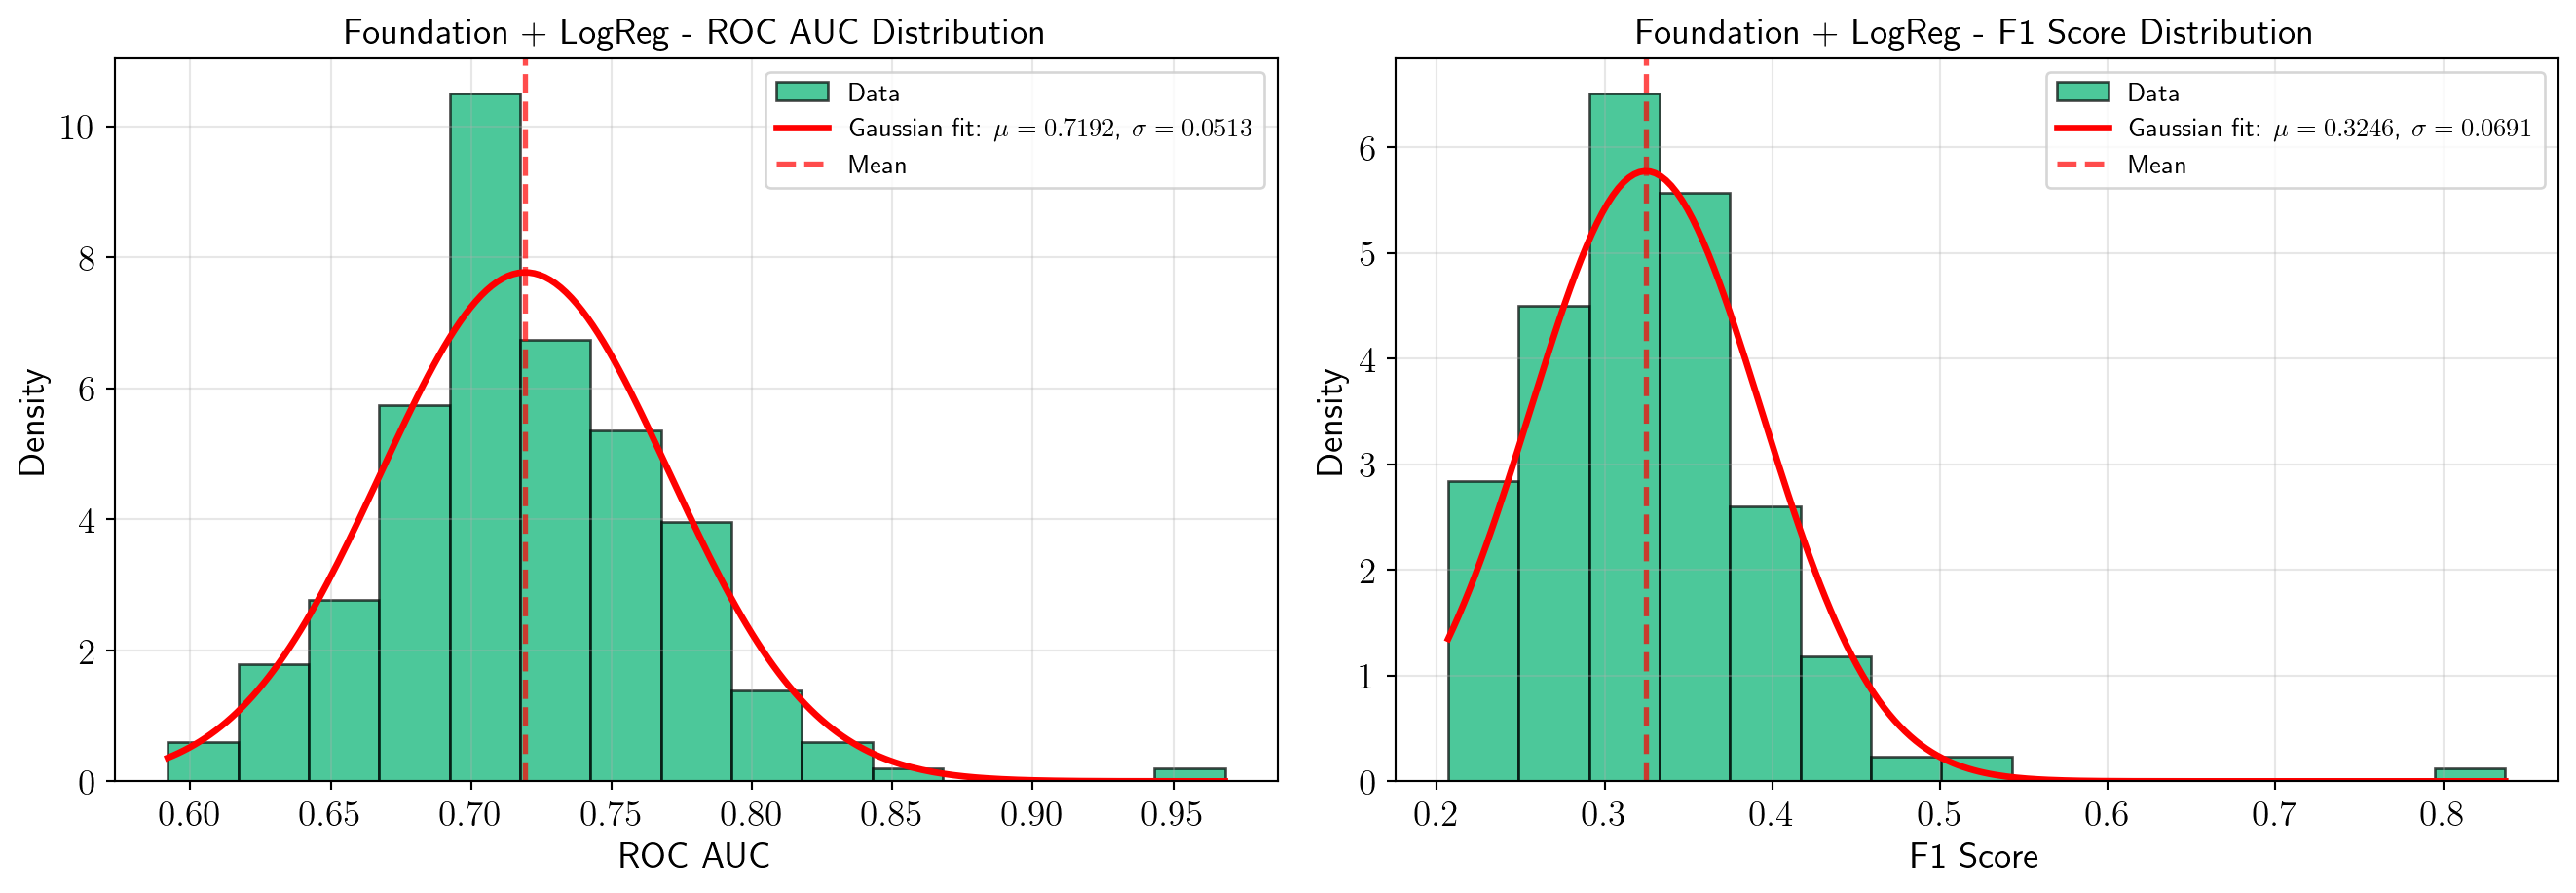

In [13]:
# Plot distributions with fitted Gaussians
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=192)

# ROC AUC distribution
ax = axes[0]
counts, bins, patches = ax.hist(foundation_roc_auc, bins=15, color='#00b170', alpha=0.7, 
                                  edgecolor='black', density=True, label='Data')

# Fit and plot Gaussian
x_roc = np.linspace(foundation_roc_auc.min(), foundation_roc_auc.max(), 200)
gaussian_roc = stats.norm.pdf(x_roc, roc_auc_mean, roc_auc_std)
ax.plot(x_roc, gaussian_roc, 'r-', linewidth=2.5, 
        label=fr'Gaussian fit: $\mu={roc_auc_mean:.4f}$, $\sigma={roc_auc_std:.4f}$')

ax.axvline(roc_auc_mean, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
ax.set_xlabel('ROC AUC', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_title('Foundation + LogReg - ROC AUC Distribution', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# F1 Score distribution
ax = axes[1]
counts, bins, patches = ax.hist(foundation_f1, bins=15, color='#00b170', alpha=0.7, 
                                  edgecolor='black', density=True, label='Data')

# Fit and plot Gaussian
x_f1 = np.linspace(foundation_f1.min(), foundation_f1.max(), 200)
gaussian_f1 = stats.norm.pdf(x_f1, f1_mean, f1_std)
ax.plot(x_f1, gaussian_f1, 'r-', linewidth=2.5, 
        label=fr'Gaussian fit: $\mu={f1_mean:.4f}$, $\sigma={f1_std:.4f}$')

ax.axvline(f1_mean, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
ax.set_xlabel('F1 Score', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_title('Foundation + LogReg - F1 Score Distribution', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Identify and analyze outliers
# For ROC AUC
roc_auc_max = foundation_roc_auc.max()
roc_auc_outlier_prob = 1 - foundation_logreg_distributions["roc_auc"]["distribution"].cdf(roc_auc_max)

# For F1 Score
f1_max = foundation_f1.max()
f1_outlier_prob = 1 - foundation_logreg_distributions["f1"]["distribution"].cdf(f1_max)

# Calculate z-scores
roc_auc_zscore = (roc_auc_max - roc_auc_mean) / roc_auc_std
f1_zscore = (f1_max - f1_mean) / f1_std

print("=" * 70)
print("OUTLIER ANALYSIS - Foundation + LogReg")
print("=" * 70)
print(f"\nROC AUC:")
print(f"  Maximum value: {roc_auc_max:.6f}")
print(f"  Mean: {roc_auc_mean:.6f}, Std: {roc_auc_std:.6f}")
print(f"  Z-score: {roc_auc_zscore:.3f}")
print(f"  Probability (right tail): {roc_auc_outlier_prob:.6e} ({roc_auc_outlier_prob*100:.4f}%)")
print(f"  P-value (two-tailed): {2*roc_auc_outlier_prob:.6e}")

print(f"\nF1 Score:")
print(f"  Maximum value: {f1_max:.6f}")
print(f"  Mean: {f1_mean:.6f}, Std: {f1_std:.6f}")
print(f"  Z-score: {f1_zscore:.3f}")
print(f"  Probability (right tail): {f1_outlier_prob:.6e} ({f1_outlier_prob*100:.4f}%)")
print(f"  P-value (two-tailed): {2*f1_outlier_prob:.6e}")
print("=" * 70)

OUTLIER ANALYSIS - Foundation + LogReg

ROC AUC:
  Maximum value: 0.968372
  Mean: 0.719244, Std: 0.051333
  Z-score: 4.853
  Probability (right tail): 6.075292e-07 (0.0001%)
  P-value (two-tailed): 1.215058e-06

F1 Score:
  Maximum value: 0.837023
  Mean: 0.324600, Std: 0.069096
  Z-score: 7.416
  Probability (right tail): 6.028511e-14 (0.0000%)
  P-value (two-tailed): 1.205702e-13


Skipping sample 5: Missing classes in predictions (7 < 8)
Skipping sample 9: Missing classes in predictions (7 < 8)


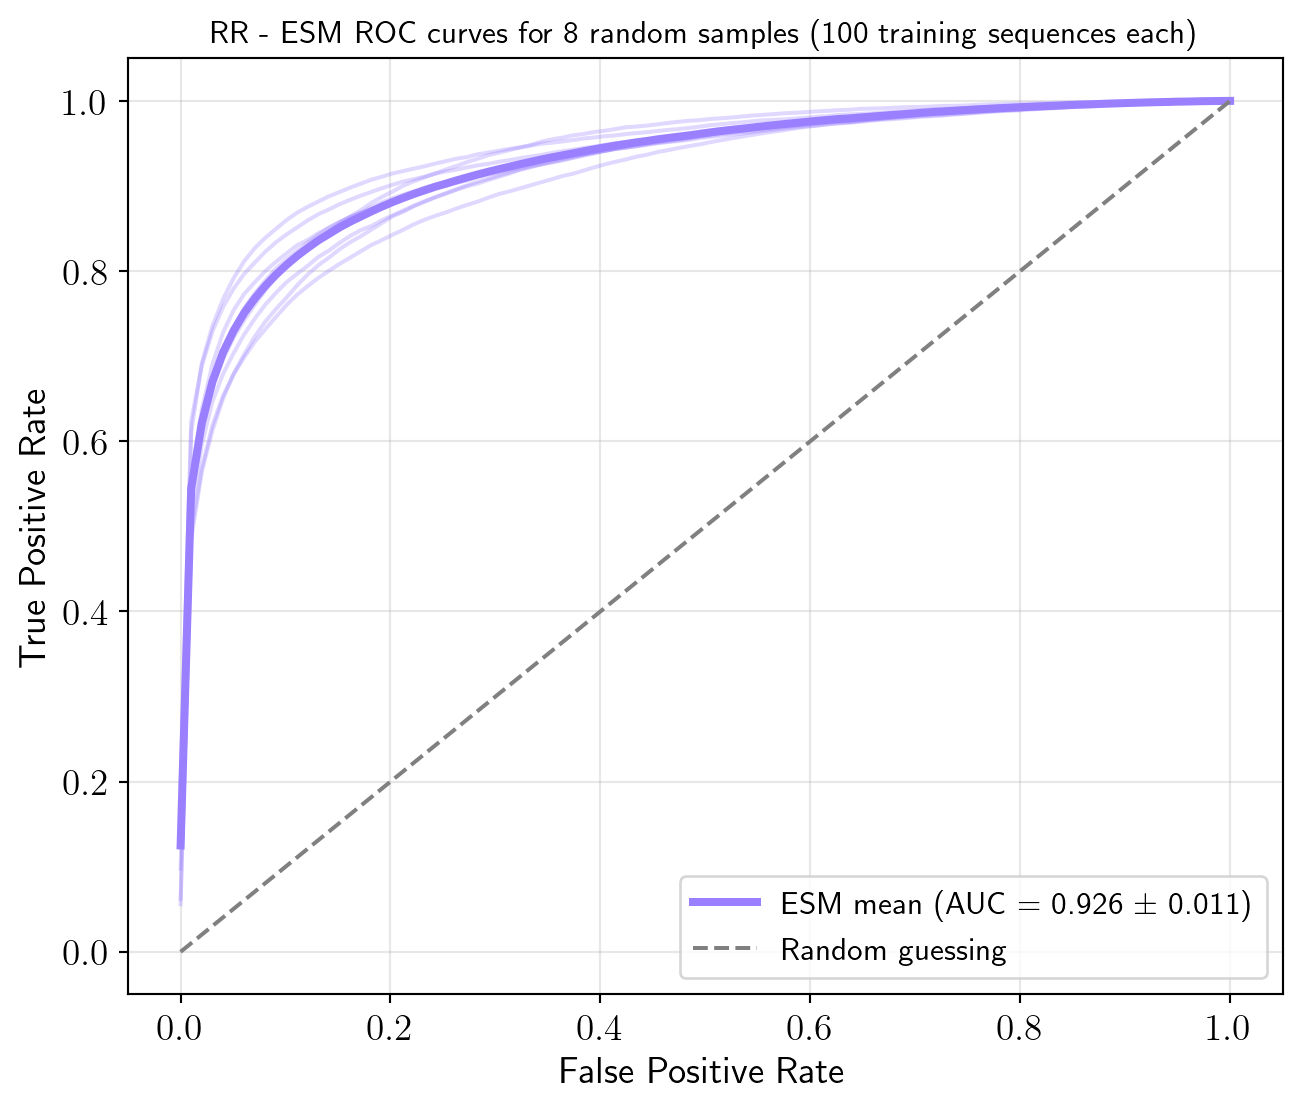

Processed 8 samples
Mean ROC AUC: 0.9263 ± 0.0107
Min ROC AUC: 0.9080
Max ROC AUC: 0.9437


In [ ]:
# Plot ROC curves for ESM using the 10 sample predictions
fig, ax = plt.subplots(figsize=(7, 6), dpi=192)

fpr = np.linspace(0, 1, 100)
tpr_samples = []
roc_auc_samples = []

# Load and plot each sample
for i in range(1, 11):
    filename = f"seed_1.test.esm.sample_{i}.predictions.h5"
    filepath = os.path.join(path_db, filename)
    
    if os.path.exists(filepath):
        try:
            with h5py.File(filepath, "r") as data:
                # Convert bytes back to strings for labels
                y_true = data["labels_true"][()].astype(str)
                y_prob = data["predictions"]["logreg"]["labels_probs"][()]
                
                # Check if dimensions match
                n_classes_true = len(np.unique(y_true))
                n_classes_pred = y_prob.shape[1]
                
                if n_classes_pred < n_classes_true:
                    print(f"Skipping sample {i}: Missing classes in predictions ({n_classes_pred} < {n_classes_true})")
                    continue
                
                _, tpr, roc_auc = multiclass_average_roc(y_true, y_prob)
                tpr_samples.append(tpr)
                roc_auc_samples.append(roc_auc)
                
                # Plot each curve with some transparency
                ax.plot(fpr, tpr, color='#9a80ff', alpha=0.3, linewidth=1.5)
        except Exception as e:
            print(f"Error processing sample {i}: {e}")
            continue

if len(tpr_samples) > 0:
    # Calculate and plot mean curve
    mean_tpr = np.mean(tpr_samples, axis=0)
    mean_auc = np.mean(roc_auc_samples)
    std_auc = np.std(roc_auc_samples)

    ax.plot(fpr, mean_tpr, color='#9a80ff', linewidth=3, 
            label=fr'ESM mean (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})')

    # Plot random guessing line
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing', linewidth=1.5)

    ax.set_xlabel('False Positive Rate', fontsize=14)
    ax.set_ylabel('True Positive Rate', fontsize=14)
    ax.set_title(f'RR - ESM ROC curves for {len(tpr_samples)} random samples (100 training sequences each)', fontsize=12)
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Processed {len(roc_auc_samples)} samples")
    print(f"Mean ROC AUC: {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"Min ROC AUC: {min(roc_auc_samples):.4f}")
    print(f"Max ROC AUC: {max(roc_auc_samples):.4f}")
else:
    print("No valid samples found to plot")